In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


from flame_net.lib_uti import count_learnable_params
from flame_net.lib_uti import Cdata_sys, count_learnable_params, lib_Model,lib_DataGen,LpLoss,lib_ModelTrain

from flame_net.libSiva import CSolverSiva
from flame_net.libKDV  import CSolverKDV
#from flame_net.uti_plot import *
import os

from flame_net.libSiva import libSiva
from flame_net.libData import libData


%matplotlib inline
import pickle

#np.random.seed(seed=1653)
from fractions import Fraction

In [2]:
#------ Load ground truth data for KDV equation ----------
if os.path.isfile ('test_all_KDV_plot2d')  : 
    with open('test_all_KDV_plot2d', "rb") as open_file:
        data_load = pickle.load(open_file)
        print('load test_all_KDV_plot2d')
        test_all_KDV = data_load['test_all_KDV']
        del data_load
    print('test_all_KDV.shape=', test_all_KDV.shape)
    
else:
    open_file = open('./data/KDV2dSq_dsol_multraj385L501_Lpi10_N128_rand_FFT.pkl', 'rb' )
    data_load = pickle.load(open_file)
    open_file.close()
    dsol_multraj = data_load['dsol_multraj']
    
    dsol_multraj = dsol_multraj[-5:]
    #dsol_multraj = dsol_multraj[:5]
    # dsol_multraj.shape = (5, 501, 128, 128)
    del data_load
    
    # ---
    len_seq = 4000
    test_all_KDV = np.zeros( ( 5, len_seq, *(2*[128])  ) )
    solver_KDV= CSolverKDV( nDIM = 2)
    for i in range( 5 ):
        test_all_KDV[i,...] = solver_KDV.generate_dsol_single(len_seq, 10,  dsol_multraj[i,0]  )# init_op_string )
        print('', end ='')
    
    # ---
    test_all_KDV = test_all_KDV.reshape(10,2000,128,128)
    del dsol_multraj

    
    # -- save to file --
    open_file = open('test_all_KDV_plot2d', "wb")
    pickle.dump( {'test_all_KDV':test_all_KDV}, open_file)
    open_file.close()
    print('saving test_all_KDV_plot2d' ) 



load test_all_KDV_plot2d
test_all_KDV.shape= (10, 2000, 128, 128)


In [3]:
# from matplotlib import cm
# MMM = 5
# fig,axs = plt.subplots(2,MMM, figsize=(10,3.5))
# for i in range(MMM):
#    axs[0,i].contourf( test_all_KDV[0,  100*i,:,:], levels= np.linspace(-3, 3, 50) , cmap=cm.jet )
#    axs[1,i].contourf( test_all_KDV[2,  100*i,:,:], levels= np.linspace(-3, 3, 50) , cmap=cm.jet )
#    axs[0,i].axis('off')
#    axs[1,i].axis('off')

In [4]:
device = torch.device('cuda')
T_in=1
data_channel = 1 # model.data_channel

#beta_dict = {15:0,25:1}
beta_dict = {15:0}
rho_dict  = {0:0, 0.5:1,  1:2}

beta_all =[15]
num_beta = len(beta_all)

In [5]:
#plt.contourf(test_KDV[-1,-1])
#test_KDV.shape

In [6]:
#------ Load ground truth for Sivashinky equation ----
N=128
def load_2d_test(beta=15, rho=1):
    T_out = 20
    N     = 128
    if beta==25 and rho==1:   ParentDir="../ml_2dflame_extra/database{:g}".format(N)
    else:                     ParentDir="../ml_2dflame/database{:g}".format(N)

    TimeFact=280
    Lpi, rho = beta, rho
    beta     = format(Lpi, '03')
    dRat     =(format(rho, '.2f'))
    fullpath=(ParentDir+'/'+'beta'+beta+'/'+'dRat'+dRat)
    # load the training data and chop up the simulation into the required format
    
    Sims =  45
    SimsTest=5
    PhiHatSols_all=np.zeros(( (SimsTest),8000,N,N),dtype=np.float32)
    for n in range(SimsTest):       
        
        counter=format(n+Sims, '02')
        filename='Run'+counter+'.npy'
        file=fullpath+'/'+filename
        print( file )
        PhiHatSols_all[n,:,:,:] =np.load(file)

    return PhiHatSols_all  

test_all = np.zeros( (num_beta, len(rho_dict), 5, 4000,N,N) )
for i,beta in enumerate( beta_all ):
    for j,rho in enumerate([0, 0.5, 1]):
        test_all[i,j,:,:,:,:] = load_2d_test(beta, rho ) [:,:4000,:,:]       

test_all = test_all.reshape(num_beta,len(rho_dict),-1,2000,N,N)
test_all.shape

../ml_2dflame/database128/beta015/dRat0.00/Run45.npy
../ml_2dflame/database128/beta015/dRat0.00/Run46.npy
../ml_2dflame/database128/beta015/dRat0.00/Run47.npy
../ml_2dflame/database128/beta015/dRat0.00/Run48.npy
../ml_2dflame/database128/beta015/dRat0.00/Run49.npy
../ml_2dflame/database128/beta015/dRat0.50/Run45.npy
../ml_2dflame/database128/beta015/dRat0.50/Run46.npy
../ml_2dflame/database128/beta015/dRat0.50/Run47.npy
../ml_2dflame/database128/beta015/dRat0.50/Run48.npy
../ml_2dflame/database128/beta015/dRat0.50/Run49.npy
../ml_2dflame/database128/beta015/dRat1.00/Run45.npy
../ml_2dflame/database128/beta015/dRat1.00/Run46.npy
../ml_2dflame/database128/beta015/dRat1.00/Run47.npy
../ml_2dflame/database128/beta015/dRat1.00/Run48.npy
../ml_2dflame/database128/beta015/dRat1.00/Run49.npy


(1, 3, 10, 2000, 128, 128)

In [7]:
test_all_KDV.shape

(10, 2000, 128, 128)

In [8]:
#t_hat = np.fft.rfft2( test_all[0,0,0,-1,:,:] ) 

def Calc2dFlameArea(flame_surface, beta=beta_all, N=N):
    kx = np.fft.fftfreq(N, d=1/N)
    ky = np.fft.fftfreq(N, d=1/N)[:N//2+1]
    kx = kx.reshape(-1,1)
    ky = ky.reshape(1,-1)
    #FlameArea = np.zeros( flame_surface.shape[:-2] )
    beta = np.array(beta).reshape(-1,*[1 for _ in range(flame_surface.ndim -1)])
    
    f_hat = np.fft.rfft2( flame_surface ) 
    grad2 = np.fft.irfft2( 1j*f_hat*ky/beta )**2 + np.fft.irfft2( 1j*f_hat*kx/beta ) **2 
    s = (1 + grad2)**0.5

    FlameArea = np.sum( s, axis= (-2,-1) ) / N**2 
        
    return FlameArea

Area = np.zeros( test_all.shape[:-2] )
for j in range(  len(rho_dict) ):
    Area[:,j,:,:] = Calc2dFlameArea(test_all [:,j,:,:,:,:] , beta_all)

Area.shape

(1, 3, 10, 2000)

In [9]:
#plt.plot( Area[0,0,4,:], 'k-' )
#plt.plot( Area[0,0,7,:], 'k--' )
#plt.plot( Area[0,1,4,:], 'b' )
#plt.plot( Area[0,1,7,:], 'b--' )
#plt.plot( Area[0,2,4,:], 'r' )
#plt.plot( Area[0,2,7,:], 'r--' )

In [10]:
#np.min(test_all [1,1,-1,2000,:,:] )

In [11]:
# import plotly.offline as pyo
# import plotly.graph_objs as go
# # Set notebook mode to work in offline
# pyo.init_notebook_mode()

# n0 = 6850


# fig = go.Figure(
#     data=[go.Surface(z= test_a[1,n0,:,:] )],  # To speed up the 3D surface-plot, we skip every 2 points
#     layout=go.Layout(updatemenus=[dict(type="buttons", buttons=[dict(label="Play", method="animate", args=[None])])]),
#     frames=[go.Frame(data=[go.Surface(z=data_i)], name=str(i)) for i, data_i in enumerate(test_a[1,n0:n0+250:50,:,:])],
# )

# fig.update_layout(  scene = dict(    zaxis = dict(range=[-80,80],),),
#                     width=1000,
#                     height=1000,
#                     margin=dict(r=10, l=10, b=10, t=10),
#                     #title="",
#                    )
# fig.update_traces(showscale=True)
# fig.show()


In [12]:
#models[3]['Lpi25rho1_list_pred'].shape
test_all.shape

(1, 3, 10, 2000, 128, 128)

In [13]:
#models[3] = {'alias':'RevtFNO151_e','act_para':[15,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO2D_Nx128_m64_64rm32_32w20Lpi_rho15_1_tAdvD1_exp_o20','proj_dir':'.'   }

In [14]:
#import kaleido
#fig.write_image("Fig_b25r0.png")

#{'alias':'RevtFNO151_e','act_para':[15,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO2D_Nx128_m64_64rm32_32w20Lpi_rho15_1_tAdvD1_exp_o20_ep900','proj_dir':'.'   },
models=[
  {'alias':'RevtFNO150_n','act_para':[15,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO2D_Nx128_m64_64rm32_32w20Lpi_rho15_0_tAdvD1_exp_nonl_o20','proj_dir':'.'    },
  {'alias':'RevtFNO151_n','act_para':[15,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO2D_Nx128_m64_64rm32_32w20Lpi_rho15_1_tAdvD1_exp_nonl_o20','proj_dir':'.'    },
  {'alias':'RevtFNO150_e','act_para':[15,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO2D_Nx128_m64_64rm32_32w20Lpi_rho15_0_tAdvD1_exp_o20'     ,'proj_dir':'.'},
  {'alias':'RevtFNO151_e','act_para':[15,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'RevtFNO2D_Nx128_m64_64rm32_32w20Lpi_rho15_1_tAdvD1_exp_o20','proj_dir':'.'   },
  {'alias':'tFNO150'     ,'act_para':[15,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO2D_Nx128_m64_64w20Lpi_rho15_0_share_o20'                       ,'proj_dir':'../ml_paraflame2023'   },
  {'alias':'tFNO151'     ,'act_para':[15,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO2D_Nx128_m64_64w20Lpi_rho15_1_share_o20'                          ,'proj_dir':'../ml_paraflame2023'},
  {'alias':'tFNO150_k1'  ,'act_para':[15,0], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO2D_Nx128_m64_64w20Lpi_rho15_0_share_o20_k1'                       ,'proj_dir':'../ml_paraflame2023'},
  {'alias':'tFNO151_k1'  ,'act_para':[15,1], 'para_name':'Lpi_rho','para_list':[], 'model_name_detail':'tFNO2D_Nx128_m64_64w20Lpi_rho15_1_share_o20_k1'                       ,'proj_dir':'../ml_paraflame2023'},
]


In [15]:

models_KDV =[
  {'alias':'RevtFNO100_n','act_para':[10,0], 'para_name':'LpiKDV','para_list':[], 'model_name_detail':'run3_RevtFNO2D_Nx128_m64_64w20LpiKDV10_tAdvD1_exp_nonl_o20','proj_dir':'.'    },
  {'alias':'RevtFNO100_e','act_para':[10,0], 'para_name':'LpiKDV','para_list':[], 'model_name_detail':'RevtFNO2D_Nx128_m32_32w20LpiKDV10_tAdvD1_exp_o20'           ,'proj_dir':'.'},
  {'alias':'tFNO100'     ,'act_para':[10,0], 'para_name':'LpiKDV','para_list':[], 'model_name_detail':'tFNO2D_Nx128_m64_64w20LpiKDV10_o20'                          ,'proj_dir':'.'   },
  #{'alias':'tFNO100'     ,'act_para':[10,0], 'para_name':'LpiKDV','para_list':[], 'model_name_detail':'run2_tFNO2D_Nx128_m64_64w20LpiKDV10_o20'                          ,'proj_dir':'.'   },
  {'alias':'tFNO100_k1'  ,'act_para':[10,0], 'para_name':'LpiKDV','para_list':[], 'model_name_detail':'tFNO2D_Nx128_m64_64w20LpiKDV10_o20_k1'                       ,'proj_dir':'.'},
]

In [16]:

# models_KDV =[
#   {'alias':'RevtFNO100_n','act_para':[10,0], 'para_name':'LpiKDV','para_list':[], 'model_name_detail':'RevtFNO2D_Nx128_m64_64w20LpiKDV10_tAdvD1_exp_nonl_o20','proj_dir':'.'    },
#   {'alias':'RevtFNO100_e','act_para':[10,0], 'para_name':'LpiKDV','para_list':[], 'model_name_detail':'RevtFNO2D_Nx128_m32_32w20LpiKDV10_tAdvD1_exp_o20'           ,'proj_dir':'.'},
#   {'alias':'tFNO100'     ,'act_para':[10,0], 'para_name':'LpiKDV','para_list':[], 'model_name_detail':'tFNO2D_Nx128_m32_32w20LpiKDV10_o20'                       ,'proj_dir':'.'   },
#   {'alias':'tFNO100_k1'  ,'act_para':[10,0], 'para_name':'LpiKDV','para_list':[], 'model_name_detail':'tFNO2D_Nx128_m32_32w20LpiKDV10_o20_k1'                       ,'proj_dir':'.'},
# ]


In [54]:
change_to_new_model('tFNO100','run2_tFNO2D_Nx128_m64_64w20LpiKDV10_o20', models=models_KDV)

model_index= 2 , to be changed model name is: tFNO2D_Nx128_m32_32w20LpiKDV10_o20
change to  run2_tFNO2D_Nx128_m64_64w20LpiKDV10_o20
model  deleted
LpiKDV10_list_pred  deleted
LpiKDV10_list_NormalizedTotalLen_pred  deleted


In [17]:
def change_to_new_model(model_alias, new_model_name_detail=None, models=models):
    for k, model in enumerate(models):
        if model['alias'] == model_alias: 
            print('model_index=', k, ', to be changed model name is:' , model['model_name_detail'] )
            if new_model_name_detail is None: 
                for i, s in enumerate( model):
                    print (i, s)
                return
            break
    model['model_name_detail']= new_model_name_detail
    print('change to ', new_model_name_detail)
    model['para_list'] = []

    key_pop_list = []    
    for j,  key in enumerate(model):
        if j >= 6:
            key_pop_list.append( key)

    for key in key_pop_list:
        print(key, ' deleted')
        model.pop(key, None)
                        
                
    return

In [18]:
#models[1]

In [19]:
def load_pkl( m ):
    str_filename = m['model_name_detail'] 
    if str_filename.find('_ep') >=0:         str_filename  = str_filename[ : str_filename.find('_ep') ]
    if str_filename.find('_best')>=0:        str_filename  = str_filename[ : str_filename.find('_best') ]
    open_file=open( m['proj_dir']+'/checkpoints/'+str_filename+ 'trainlog.pkl','rb')
    output_dict= pickle.load(open_file)
    open_file.close()
    train_residual = np.array ( [ os for os  in output_dict['list_output_info'] ] )
    return train_residual 
    
def plot_training_resid( m, list_iy=[2,3], ys='log',ix=0):
    train_residual = load_pkl( m)
    line_style = ['r-', 'g-.','b--','k.']
    for idx, y in enumerate(list_iy):
        plt.plot( train_residual[:,ix], train_residual[:,y], line_style[idx])
    plt.yscale(ys)
    
    return [ train_residual[:, y ][-1] for  y in list_iy ]

def print_train_info( list_iy=[2,3,1], models=models ):
    for idx, m in enumerate( models):
        train_residual = load_pkl( m)
        #----------------
        if 'ONet' in m['model_name_detail']:            method='ONet'
        elif  'FNO' in m['model_name_detail']:      method='Fourier'
        elif  'Conv' in m['model_name_detail']:         method='Conv'
        #----------------
        print(idx, method, m['model_name_detail'], m['nStep'] ,m['Tout'],  [ train_residual[:, y ][-1] for  y in list_iy ] ) 

In [20]:
#plot_training_resid (  models[0], [2,3],  ys='log' )

In [21]:
# list__init_str = 10*['rand_simple']
# list__init_str_LongTerm= np.arange(10)
# list_randseed = np.arange(10)+457
# siva = [
#   {'para_name':'Lpi_rho', 'para_list':[], 'SivaEq':CSolverSiva('MKS_RK4', [[10,0], [40,1]], method_default_siva_data_gen=4), 'N':256 ,'list_randseed':list_randseed  },
# ]


In [22]:
#
# list__init_str =4*['rand_simple']
# list__init_str_LongTerm=[3]
# list_randseed = [1333,121283,112639,12219 ]
# siva = [  {'para_name':'Lpi_rho', 'para_list':[], 'SivaEq':CSolverSiva('MKS_RK4', [[10,0], [40,1]], method_default_siva_data_gen=4), 'N':256 ,'list_randseed':list_randseed  },]
#


In [23]:
def get_para_key( para_name, each_para_value, PDE=''):  # note: 'each_para_value' is allowed to be a list of values
    if PDE == 'KDV':
        return 'LpiKDV10_'
    else:
        if 'Lpi_rho'== para_name:   return 'Lpi{:d}rho{:g}_'.format(each_para_value[0],each_para_value[1])
        else:                       return '{}{:.3f}_'.format(para_name, each_para_value)
    
def get_d0(i_which, each_para_value, PDE=''):
    if PDE == 'KDV':
        return test_all_KDV[i_which,0,:,:]
    else: 
        i,j = beta_dict[each_para_value[0]], rho_dict[each_para_value[1]]
        return test_all[i,j,i_which, 0,:,:]

def get_d0_all_from_para(each_para_value, PDE=''): # nu
    d0_all=[]
    num_i_which = 10

    for i_which in range(num_i_which): 
        d0 = get_d0(i_which, each_para_value, PDE)
        d0_all.append(d0)
    return np.array( d0_all )



In [24]:
num_total_step=2000

def load_model( model_name_detail, proj_dir):
    LocalFull_filename_Saved_Model = proj_dir +  '/checkpoints/' + model_name_detail
    model = torch.load( LocalFull_filename_Saved_Model, map_location='cuda')
    print(model_name_detail, ' loaded in: count_learnable_params =' + str( count_learnable_params(model) ))
    return model

def get_model(name, para_name,each_para_value,  PDE='', bLoadModel=True ): # models,

    if PDE == 'KDV': 
        models_actual = models_KDV
    elif PDE == 'KDV2':
        models_actual = models_KDV2
    else:
        models_actual = models
    
    for m in models_actual:
        list_keywords = [ para_name.casefold() ] 
        
        #print( 'list_keywords=',list_keywords, "m['alias']==name", m['alias'] , name , "m['model_name_detail']",m['model_name_detail'])
        
        if m['alias']==name and all( [keyword in m['model_name_detail'].casefold() for keyword in list_keywords ] ):
            if 'model' not in m  and bLoadModel==True:
                m['model'] = load_model( m['model_name_detail'] ,  m['proj_dir'] )
            if each_para_value not in m['para_list']:
                assert each_para_value == m['act_para'] ,(each_para_value, m['act_para'] )
                m = update_model_pred( m,  {'para_name':para_name,'para_list':[each_para_value] } , PDE )
            return m
            
    print( m['model_name_detail'])                
    raise ValueError('did not find model')

def update_model_pred(m,  para_dict, PDE=''):
    m = get_model_pred(m, para_dict, PDE)
    return m

def get_model_pred(m,  para_dict, PDE='' ):
    para_name = para_dict['para_name']
    para_list = para_dict['para_list']


    NotYetReady__para_list = []
    for each_para_value in para_list:
        if each_para_value not in m['para_list']:
            NotYetReady__para_list.append(each_para_value)

    #-----
    for each_para_value in NotYetReady__para_list:
        each_para_key = get_para_key(para_name, each_para_value,PDE)
        d0       = get_d0_all_from_para(each_para_value, PDE)
                
        d0_torch = torch.tensor(d0,dtype=torch.float).unsqueeze(-1)

        model = m['model']
        model.eval()
        
        with torch.no_grad():
            
            xx = d0_torch
            xx = xx.to(device)

            batch_size = xx.shape[0]
            
            if '_k1' in m['model_name_detail']:      #  print('debug_test_else', xx) 

                for t in range(num_total_step):
                    im = model(xx )    # ,pdepara  )  

                    if t == 0:     pred = torch.cat((  xx, im), -1)
                    else:          pred = torch.cat((pred, im), -1)

                    xx = im
                    
            else:                         # if '_O' in m['model_name_detail']:
                
                T_out = 20 # 100
                for t in range(num_total_step//T_out):
                    im = model(xx )     # , pdepara   )  
                    im = im.view( *im.shape[:-2], im.shape[-1] )
                    #--------------------
                    #print(t, 'im.shape=', im.shape, 'xx.shape=',xx.shape)
                    if t == 0:     pred = torch.cat((  xx, im[...,:T_out]), -1)
                    else:          pred = torch.cat((pred, im[...,:T_out]), -1)
                    #xx = im[...,-1:]
                    xx = im[...,T_out-1:T_out]
            
        m['para_list'].append(each_para_value)
    
        list_pred = pred.detach().cpu().numpy()                   # list_pred.shape == (4, 512, 2000)
       
        m[each_para_key+'list_pred'] = np.moveaxis(list_pred,-1,1)

        #m['list_pred'] = np.moveaxis(list_pred,1,-1)
        
        print(each_para_key+'list_pred.shape=', m[each_para_key+'list_pred'].shape)

        #----
        # nu = m['nu']
        # sys = get_sys(nu)    
        #----
        m[each_para_key+'list_NormalizedTotalLen_pred'] = Calc2dFlameArea( m[each_para_key+'list_pred'],each_para_value[0])
        
        #libData.dsol_to_whole_length(m['x'], m[each_para_key+'list_pred']  )

    return m

In [25]:
# def alias_to_lengend_txt( model_alias ):
#     n = model_alias.find('FNO') + 3  # '3' means '401', '100', etc...
#     model_alias = model_alias[:n] + model_alias[n+3:]
#     if model_alias == 'RevtFNO': return "rev-$kFNO$"
#     if model_alias == 'RevtFNO_e': return "rev-$kFNO^*$"  
#     if model_alias == 'RevtFNO_n':  return "rev-$kFNO'$"   
#     if model_alias == 'RevtFNO_k3': return "rev-$kFNO^*_{\kappa3}$"  
#     if model_alias == 'RevtFNO_k':  return "rev-$kFNO^*_{\kappa}$"   
#     if model_alias == 'RevtFNO_roll': return "rev-$kFNO^*_{roll}$"   
#     if model_alias == 'Rev222tFNO_e':  return "rev_3-$kFNO^*$"   
    
#     if model_alias == 'tFNO':  return "$kFNO$"           
#     if model_alias == 'tFNO_e': return "$kFNO^*$"       
#     if model_alias == 'tFNO_n': return "$kFNO'$"       
#     if model_alias == 'tFNO_k1': return"$FNO$"        
#     return model_alias    

def alias_to_lengend_txt( model_alias ):

    n = model_alias.find('FNO') + 3  # '3' means '401', '100', etc...
    
    model_alias = model_alias[:n] + model_alias[n+3:]
    
    if model_alias == 'RevtFNO': return "IS-FNO$^*$"
    if model_alias == 'RevtFNO_e': return "IS-FNO'"  
    if model_alias == 'RevtFNO_n':  return "IS-FNO$^o$"   
    if model_alias == 'RevtFNO_k3': return "IS-FNO'$_{\kappa3}$"  
    if model_alias == 'RevtFNO_k':  return "IS-FNO'$_{\kappa}$"   
    if model_alias == 'RevtFNO_roll': return "IS-FNO'$_{roll}$"   
    if model_alias == 'Rev222tFNO_e':  return "IS_3-FNO'"   
    
    if model_alias == 'tFNO':    return "kFNO$^*$"           
    if model_alias == 'tFNO_e':  return "kFNO'"       
    if model_alias == 'tFNO_n':  return "kFNO$^o$"       
    if model_alias == 'tFNO_k1': return "FNO"        
    
    return model_alias    


In [26]:
def plot_para_len ( all_list_models_for_cmp, all_list_init,  png_filename=None, ylim=(0.9,2.1) , models= models  ):

    num_steps_for_plot= 2000
    nRow_per_init = 1 #
    
    #fig, axs = plt.subplots(nRow_per_init*len( all_list_models_for_cmp[0] ),len(all_list_init),sharex=True, sharey=True,figsize= [12,0.8*2*len(all_list_models_for_cmp[0])*nRow_per_init ])
    fig, axs = plt.subplots(nRow_per_init*len( all_list_models_for_cmp[0] ),len(all_list_init),sharex=True, figsize= [12, 1.5*len(all_list_models_for_cmp[0])*nRow_per_init ])

    for idx_ , list_models_for_cmp in enumerate(all_list_models_for_cmp):
        for  i_nu, models_for_cmp in enumerate(list_models_for_cmp):
            #---
            #print(i_nu,  models_for_cmp)
            m_all       = [ get_model(**m_  ) for m_ in models_for_cmp]

            #---
            each_para_key_all = [ get_para_key( m_['para_name'], m_['each_para_value']) for m_ in models_for_cmp] 
            pred_all          = [ m_[each_para_key+'list_pred'] for m_ , each_para_key in zip(m_all,each_para_key_all) ]     
            #---

            #print('idx_=', idx_, 'm_all[0][act_para][1]=', m_all[0]['act_para'][1] , 'rho_dict=', rho_dict ) 
            
            i_beta, j_rho = beta_dict [ m_all[0]['act_para'][0] ] , rho_dict [ m_all[0]['act_para'][1] ] 
            
            len_an_all        = Area[i_beta,j_rho,:, :num_steps_for_plot ]   # m_all[0]['sys'] [each_para_key_all[0]+'list_NormalizedTotalLen_an']
            len_pred_all      = [ m_[each_para_key_all[idx]+'list_NormalizedTotalLen_pred'] for idx, m_ in enumerate(m_all) ] 


            #----------------------
            list_plot_style = ['-r','-.b',':c','--g', ':m',':b']
            #--------------------------------------------------------------------
            #list_legend =['Ref'] +  ['$'+ m['name'] + '$' for m in models_for_cmp ]
            list_legend =['Ref'] +  [ alias_to_lengend_txt(m['name'])  for m in models_for_cmp ]

            ax = axs[i_nu,idx_ ]
            ################################
            i_d0 = all_list_init[idx_][0]

            ax.set_yticks( [ 1, 1.5, 2 ] )
            ax.set_yticklabels(['1', '1.5' , '2'], rotation='vertical',  fontsize=12 )
            ax.set_xticks( [ 0,  500, 1000, 2000] )
            ax.set_xticklabels(['0','500', '1000' ,'2000'], fontsize=12)
            ax.set_xlabel( 't/0.074', fontsize=14) 
            #ax.set_ylim(.9,2.1)
            
            ax.set_ylim(*ylim)
            if i_nu > 0: 
                ax.set_ylim(0.99,1.6)


            len_an = len_an_all[i_d0]
            nnn=np.arange( num_steps_for_plot)

            ax.plot( nnn, len_an[:num_steps_for_plot],'--k' , lw=1)
            list_len_pred = [ len_[i_d0] for len_ in  len_pred_all ] 

            for idx, len_pred in enumerate( list_len_pred):
                nnn = np.arange( num_steps_for_plot    )  
                ax.plot(nnn, len_pred[:num_steps_for_plot], list_plot_style[idx] , lw=1)

                
            #ax.legend(list_legend , ncol=2,  loc='lower right', fontsize=10)
            if i_nu==0 and idx_== len(all_list_init)-1:
                ax.legend(list_legend , ncol=3,  loc='lower right', fontsize=12, frameon=True, borderpad=0,labelspacing=0.1)
                
                #ax.set_title(r'$\beta={:g}$'.format(models_for_cmp[0]['each_para_value'][0] ) , fontsize=14 ) 

            if idx_== len(all_list_init)-1: 
                #ax2 = ax.twinx()
                ax.yaxis.set_label_position("right")
                para = models_for_cmp[0]['each_para_value']
                #list_RightText =  r"$\beta={:g},\rho={}$".format(para[0], Fraction(para[1]) )
                txt_instablity = '2D-MS' if para[1]==1  else '2D-KS' 
                list_RightText = txt_instablity + r', $\beta$={}'.format( para[0])

                #list_RightText =  r"$\rho={}$".format( Fraction(para[1])   )
                ax.set_ylabel(list_RightText,  fontsize=12  )
            ########################################################

            #-----------
    for ax in axs.flat:
        ax.label_outer()

    plt.subplots_adjust(left=0.073, right=0.975, top=0.975, bottom=0.15, wspace=0.02, hspace=0.02)
    
    fig.text(0.001, 0.52, 'Normalized total 2d-front area \n    $    \int (\phi_x^2+\phi_y^2 +1 )^{1/2} dx /(4\pi^2)  $  ', va='center', rotation='vertical',fontsize=13)

    #---------------------
    if png_filename is not None:
        print('savefig: ', png_filename)
        if 'eps' in png_filename:
            plt.savefig(png_filename, format='eps')
        else:
            plt.savefig(png_filename, dpi=300)            


In [27]:
#all_list_init = [ [0],[2],[4],[6],[8]]
all_list_init = [ [0],[2],[6],[8]]
#all_list_init = [ [1],[3],[5],[7],[9]]

all_list_para_values =[   [15,1],   [15,0]  ]


#all_list_model_names =[  ['RevtFNO151_n','RevtFNO151_e'],['RevtFNO150_n','RevtFNO150_e']  ]
all_list_model_names =[  ['RevtFNO151_n','tFNO151'],['RevtFNO150_n','tFNO150']  ]

all_list_models_for_cmp =[  [ [{'name':model_name, 'para_name':'Lpi_rho','each_para_value': para_value } 
                             for model_name in list_model_names     ] 
                             for list_model_names, para_value in zip(all_list_model_names, all_list_para_values) ]
                             for j,_  in enumerate(all_list_init)     ]
#------------------------------------

#png_filename =  'len_2Dfront.eps'
#plot_para_len ( all_list_models_for_cmp, all_list_init , png_filename, ylim=(0.98,1.9), models= models)


In [28]:
def get_corr(data,cases_valids=None, N=N):
    k0 = np.fft.fftfreq(N,1/N).reshape(-1,1)
    k1 = np.fft.fftfreq(N,1/N)[:N//2+1].reshape(1,-1)
    kk=np.sqrt(k0**2+k1**2)
    
    
    pre_shape = data.shape[:-4]
    spectrum = np.zeros(  (*pre_shape, N) )
    
    print('spectrum.shape=', spectrum.shape)
    if cases_valids is None:
        cf = np.fft.rfft2 ( data[...,1000:,:,:] )
    else: 
        cf = np.fft.rfft2 ( data[...,cases_valids,1000:,:,:] )
        
    print('cf.shape=', cf.shape)
    for i in range(N):
        for j in range(N//2+1):
            idx = int ( kk[i,j] )
            spectrum[...,idx] += np.average(  np.abs(cf[...,i,j])**2  , axis = (-2,-1) )    #kk[...,i,j]**2 

    corr=np.fft.irfft(spectrum[...,:N//2+1] ).real
    corr = corr/corr[...,0:1]
    return corr

In [29]:
corr_refence = get_corr( test_all )

spectrum.shape= (1, 3, 128)
cf.shape= (1, 3, 10, 1000, 128, 65)


In [30]:
def plot_2d_autocorrelation(list_models_for_cmp,  line_legend,  png_filename=None, models= models,ylim=None) :



    marker = [  's', None, None, 's']
    markevery =  [7,1,1,1]
    linestyle= [ ':' ,'-', '-.', '-.']
    color = ['c', 'b', 'r' , 'g']
    
    

    
    beta_i_rho_j   = [ models_for_cmp[0]['each_para_value'] for models_for_cmp in list_models_for_cmp ]

    str__para_name = [ r"2d-MS, $\beta$=15" if  models_for_cmp[0]['each_para_value'][1] == 1 else r"2d-KS, $\beta$=15" for  models_for_cmp in list_models_for_cmp ]
    #str__para_name = [ r'$\\rho$={}'.format( Fraction( models_for_cmp[0]['each_para_value'][1] ) ) for models_for_cmp in list_models_for_cmp ]    
    #print(str__para_name)
    #---------------        
    N_end = num_total_step+1 
    nCase = len( list_models_for_cmp )
    # -------------
    
    fig, axs = plt.subplots(1,nCase ,sharey=True, figsize= [6/1.2, 4.5 ], squeeze=False) 

    axs = axs.flatten()
    for ax, t1  in zip(axs, str__para_name):
        ax.set_title( t1, fontsize= 18 ) #, pad=15)
    
    for icase, models_for_cmp in enumerate(list_models_for_cmp):
        for idx, m_info       in enumerate(models_for_cmp):
            m             = get_model(**m_info )  #, models= models
            each_para_key = get_para_key( m_info['para_name'], m_info['each_para_value'])  
            pred          = m[each_para_key+'list_pred'] 
            label         =  alias_to_lengend_txt(  m_info['name'])  
            
            # --------------------
            i_beta, j_rho = beta_dict [ beta_i_rho_j[icase][0] ], rho_dict [ beta_i_rho_j[icase][1] ] 
            
            # d_an = test_all[i_beta,j_rho,:,:N_end,:,:]
            if idx ==0: 
                corr_an = corr_refence[i_beta,j_rho,:N//2+1]
                axs[icase].plot( corr_an    , color='lightgrey',  linewidth=6 ,label='Ref' )

            
            corr    = get_corr( pred, cases_valids = [0,2,6])
                
                
            #axs[icase].plot( corr[:N//2+1]     , line_legend[idx]  ,linewidth=1, label = label)

            j = idx
            axs[icase].plot( corr[:N//2+1]     , linewidth=1, label = label,  linestyle=linestyle[j], marker=marker[j], color=color[j],markevery=markevery[j]  )


            str__para_name = r'$\rho$='  if models_for_cmp[0]['para_name']=='nu' else r'$\beta$=' 


            if icase == 0:
                axs[icase].legend( fontsize=16,  frameon=True, borderpad=0,labelspacing=0.1)
                
            
            #if nCase >1: 
            #    axs[icase].set_ylabel('Auto-correlation',fontsize=18)

            #-----------
    for ax in axs.flat:
        ax.label_outer()
        ax.set_xlim( [0,N//2])
        ax.set_xticks( [0,   N//2] )
        ax.set_xticklabels(['0',  '$\pi$'  ] , fontsize=14 )
        if nCase >1: 
            ax.set_xlabel('$|r|$',fontsize=18)
            ax.xaxis.set_label_coords(0.5,-0.1)

            
        ax.set_yticks( [-1/2, 0,1/2, 1] )
        ax.set_yticklabels(['-0.5', '0','0.5','1' ] , fontsize=14 )

        if ylim is not None:
            ax.set_ylim( ylim )
        
    #fig.subplots_adjust(wspace=0.06,hspace=0.02)
    fig.tight_layout( )
    plt.subplots_adjust(wspace=0.075) #, hspace=0.1)

        
    if png_filename is not None:
        print('save png: ',png_filename )
        plt.savefig(png_filename,dpi=300)

tFNO2D_Nx128_m64_64w20Lpi_rho15_0_share_o20  loaded in: count_learnable_params =9834517
Lpi15rho0_list_pred.shape= (10, 2001, 128, 128)
spectrum.shape= (128,)
cf.shape= (3, 1001, 128, 65)
tFNO2D_Nx128_m64_64w20Lpi_rho15_0_share_o20_k1  loaded in: count_learnable_params =9834517
Lpi15rho0_list_pred.shape= (10, 2001, 128, 128)
spectrum.shape= (128,)
cf.shape= (3, 1001, 128, 65)
RevtFNO2D_Nx128_m64_64rm32_32w20Lpi_rho15_0_tAdvD1_exp_nonl_o20  loaded in: count_learnable_params =20342349
Lpi15rho0_list_pred.shape= (10, 2001, 128, 128)
spectrum.shape= (128,)
cf.shape= (3, 1001, 128, 65)
tFNO2D_Nx128_m64_64w20Lpi_rho15_1_share_o20  loaded in: count_learnable_params =9834517
Lpi15rho1_list_pred.shape= (10, 2001, 128, 128)
spectrum.shape= (128,)
cf.shape= (3, 1001, 128, 65)
tFNO2D_Nx128_m64_64w20Lpi_rho15_1_share_o20_k1  loaded in: count_learnable_params =9834517
Lpi15rho1_list_pred.shape= (10, 2001, 128, 128)
spectrum.shape= (128,)
cf.shape= (3, 1001, 128, 65)
RevtFNO2D_Nx128_m64_64rm32_32w20L

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


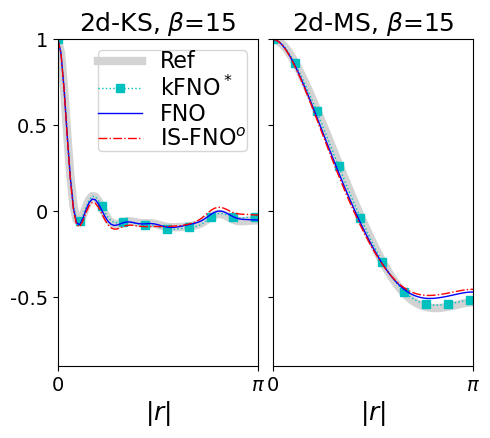

In [31]:
#bAutoCorr = True # False


All_list_para_values =[   [15,0] ,  [15,1]      ]
All_list_model_names =[     ['tFNO150', 'tFNO150_k1', 'RevtFNO150_n'] , ['tFNO151' , 'tFNO151_k1', 'RevtFNO151_n'  ]]
#All_list_model_names =[  ['RevtFNO151_n' , 'RevtFNO151_e' ],   ['RevtFNO150_n','RevtFNO150_e'] ]



list_models_for_cmp =[ [{'name':model_name, 'para_name':'Lpi_rho','each_para_value': list_para_values} for model_name in All_list_model_names[idx]  ] 
                         for idx, list_para_values in enumerate(All_list_para_values) ] 
line_legend = ['r--', 'b-.','c:','r:', 'b-','b:'] 

png_filename=  'corr_2d_siva_isFNO.eps'
plot_2d_autocorrelation(list_models_for_cmp,  line_legend,  png_filename=png_filename, models= models,  ylim=[-0.9,1] ) 



In [32]:
def plot_space_errors(list_t, list_models_for_cmp ,list_i_pickplot,  png_filename=None, models= models) : # list__i_pickplot__init_d0=[1]
    import matplotlib.gridspec as gridspec

    beta_i_rho_j   = [ models_for_cmp[0]['each_para_value'] for models_for_cmp in list_models_for_cmp ]
    str__para_name = [ 'DL'+ r', $\beta$={}'.format( models_for_cmp[0]['each_para_value'][0]) if models_for_cmp[0]['each_para_value'][1]==1  else 'DT'+ r', $\beta$={}'.format( models_for_cmp[0]['each_para_value'][0])   for models_for_cmp in list_models_for_cmp ]
    
    #---------------        
    levels= np.linspace(0,0.1,100)
    cmap= 'rainbow'

    #-----------
    N_end = num_total_step #+1
    #------
    nCase = len(list_models_for_cmp)
    num_models = len(list_models_for_cmp[0]) 
    num_pickplot = len(list_i_pickplot)
    fig, axs = plt.subplots(nCase, len(list_t),sharex=True, figsize= [4*2 ,2*len(list_models_for_cmp) ])
    
    #----------
    #for ax, t1  in zip(axs[0], ["$t/\Delta_t'=100$","$t/\Delta_t'=200$","$t/\Delta_t'=300$","$t/\Delta_t'=400$"]):
    #    ax.set_title( t1, fontsize= 15 , pad=15)
    for ax, t  in zip(axs[0], list_t):
        ax.set_title( "$t/\Delta_t'={}$".format(t), fontsize= 15 , pad=15)

    rows = ['{:g}'.format( models_for_cmp[0]['each_para_value'][0] ) for models_for_cmp in list_models_for_cmp ]
        
    #-----------------------
    for icase, models_for_cmp in enumerate(list_models_for_cmp):
        for idx, m_info       in enumerate(models_for_cmp):

            PDE = m_info['PDE']
            m             = get_model(   **m_info )  #, models= models

            i_pickplot = list_i_pickplot[0]

            if 'KDV' in PDE : 
                pred          = m['LpiKDV10_list_pred'] 
                d_an = test_all_KDV[i_pickplot,:N_end,:,:]
            else: 
                each_para_key = get_para_key(  m_info['para_name'], m_info['each_para_value'])  
                pred          = m[each_para_key+'list_pred'] 
                #label         = alias_to_lengend_txt( m_info['name'] ) 
                # --------------------
                i_beta, j_rho = beta_dict [ beta_i_rho_j[icase][0] ], rho_dict [ beta_i_rho_j[icase][1] ] 
                d_an = test_all[i_beta,j_rho,i_pickplot,:N_end,:,:]
            
            pred_pickplot =  pred[i_pickplot,:N_end,:,:]
            error_L2 = ((pred_pickplot - d_an)**2/(d_an**2).mean(axis=(-3,-2,-1),keepdims=True))**0.5 

            # pos = axs[icase, 0].contourf( error_L2[100,:,:] ,  levels = levels ,cmap=cmap )   
            # pos = axs[icase, 1].contourf( error_L2[250,:,:] ,  levels = levels ,cmap=cmap )   
            # pos = axs[icase, 2].contourf( error_L2[350,:,:] ,  levels = levels ,cmap=cmap )   
            # pos = axs[icase, 3].contourf( error_L2[450,:,:] ,  levels = levels ,cmap=cmap )   

            for kkk,t in enumerate(list_t):
                pos = axs[icase, kkk].contourf( error_L2[t,:,:] ,  levels = levels ,cmap=cmap )   


            # axs[icase,0].set_axis_off()
            # axs[icase,1].set_axis_off()
            # axs[icase,2].set_axis_off()
            for ax in axs[icase]: 
                ax.set_xticks([])
                ax.set_yticks([])

            # axs[icase,3].yaxis.set_label_position("right")            
            # axs[icase,3].set_ylabel(str__para_name[icase], fontsize=14  )
            #--------------------



    for ax in axs.flat:
        ax.label_outer()
        #ax.set_xlim([0,200])

    fig.tight_layout( )
    fig.subplots_adjust(wspace=0.05,hspace=0.05)
    
        
    if png_filename is not None:
        print('save png: ',png_filename )
        plt.savefig(png_filename,dpi=300)
        

run3_RevtFNO2D_Nx128_m64_64w20LpiKDV10_tAdvD1_exp_nonl_o20  loaded in: count_learnable_params =20342349
LpiKDV10_list_pred.shape= (10, 2001, 128, 128)
save png:  err_2d_space_dist.png


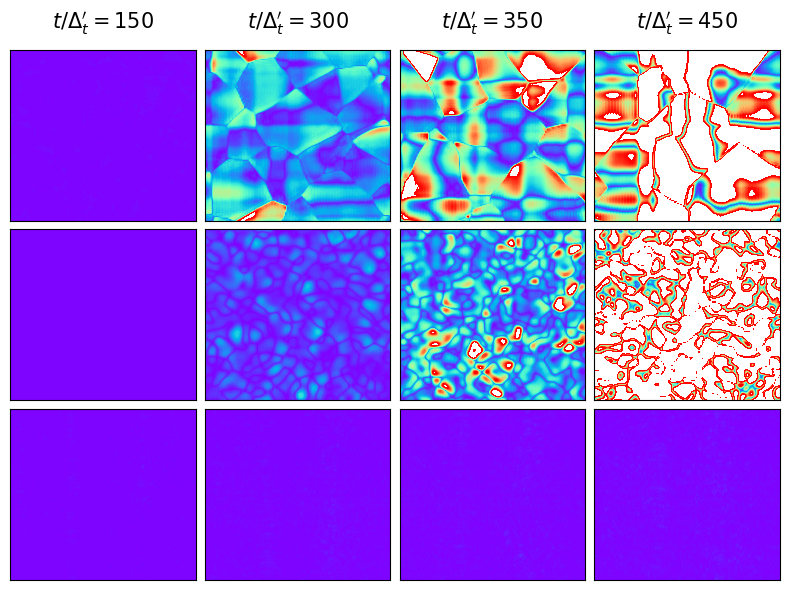

In [33]:

All_list_para_values =[      [15,1],        [15,0]  , [10,0] ]
All_list_model_names =[  ['RevtFNO151_n', ],   ['RevtFNO150_n', ] , ['RevtFNO100_n', ] ]
#All_list_model_names =[  ['RevtFNO151_n', ],   ['RevtFNO150_n', ] , ['tFNO100', ] ]
All_list_PDE = [  '',   '',   'KDV'  ]

# list_models_for_cmp =[ [{'name':All_list_model_names[idx][j], 'para_name':'Lpi_rho','each_para_value': list_para_values } 
#                          for idx, list_para_values in enumerate(All_list_para_values) ] ]
                         
list_models_for_cmp =[  [{'name':model_name, 'para_name':'LpiKDV' if PDE=='KDV' else 'Lpi_rho','each_para_value': list_para_values,'PDE':PDE} for model_name in All_list_model_names[idx]  ] 
                         for idx, (list_para_values,PDE) in enumerate( zip(All_list_para_values, All_list_PDE) ) ] 
list_t = [150,300,350,450]
    
png_filename= 'err_2d_space_dist.png'
plot_space_errors(list_t, list_models_for_cmp,  list_i_pickplot =[8], png_filename=png_filename, models= models)

In [34]:
# models_KDV[0]['model'] = load_model(models_KDV[0]['model_name_detail'], models_KDV[0]['proj_dir'] )
# models_KDV[1]['model'] = load_model(models_KDV[1]['model_name_detail'], models_KDV[1]['proj_dir'] )

run3_RevtFNO2D_Nx128_m64_64w20LpiKDV10_tAdvD1_exp_nonl_o20  loaded in: count_learnable_params =20342349
RevtFNO2D_Nx128_m32_32w20LpiKDV10_tAdvD1_exp_o20  loaded in: count_learnable_params =4189773


In [35]:
models_KDV[0]['model'].conv_timeAdv.weights.shape

torch.Size([2, 128, 64, 21, 21])

In [46]:
with torch.no_grad()  and False:
  #for i in range(1):
       i=4
       weights1 = models_KDV[0]['model'].net_reversible.F_rev_net[0][1][1].conv[0].SpectralConv.weights1[i,:] #.reshape(-1).cpu()
       #weights2 = models_KDV[0]['model'].net_reversible.F_rev_net[0][1][1].conv[0].SpectralConv.weights2[i,:] #.reshape(-1).cpu()
       plt.scatter( weights1.cpu().real,  weights1.cpu().imag )
       #plt.scatter( weights2.cpu().real,  weights2.cpu().imag )

TypeError: 'bool' object does not support the context manager protocol

In [47]:
with torch.no_grad()  and False:
   fig,axs = plt.subplots(2,2,figsize=(8,6))
   i = 5
   j = 15
   d_weights=models[0]['model'].conv_timeAdv.weights[0]
   axs[0,0].scatter( d_weights[-i:,:j,:,: ].reshape(-1).cpu().real, d_weights[-i:,:j,:,: ].reshape(-1).cpu().imag  )    
   axs[0,1].scatter( d_weights[:i,:j,:,: ].reshape(-1).cpu().real, d_weights[:i,:j,:,: ].reshape(-1).cpu().imag  )    

   d_weights=models[0]['model'].conv_timeAdv.weights[1]
   axs[1,0].scatter( d_weights[-i:,:j,:,: ].reshape(-1).cpu().real, d_weights[-i:,:j,:,: ].reshape(-1).cpu().imag  )    
   axs[1,1].scatter( d_weights[:i,:j,:,: ].reshape(-1).cpu().real, d_weights[:i,:j,:,: ].reshape(-1).cpu().imag  )    

TypeError: 'bool' object does not support the context manager protocol

In [48]:
with torch.no_grad()  and False:
   fig,axs = plt.subplots(2,2,figsize=(8,6))
   i = 5
   j = 20
   d_weights=models[1]['model'].conv_timeAdv.weights
   axs[0,0].scatter( d_weights[-i:,:j,:,: ].reshape(-1).cpu().real, d_weights[-i:,:j,:,: ].reshape(-1).cpu().imag  )    
   axs[0,1].scatter( d_weights[:i,:j,:,: ].reshape(-1).cpu().real, d_weights[:i,:j,:,: ].reshape(-1).cpu().imag  )    

   d_weights=torch.linalg.matrix_exp(models[1]['model'].conv_timeAdv.weights )-torch.eye(21,device='cuda') 
    #models_KDV[1]['model'].conv_timeAdv.weights
   axs[1,0].scatter( d_weights[-i:,:j,:,: ].reshape(-1).cpu().real, d_weights[-i:,:j,:,: ].reshape(-1).cpu().imag  )    
   axs[1,1].scatter( d_weights[:i,:j,:,: ].reshape(-1).cpu().real, d_weights[:i,:j,:,: ].reshape(-1).cpu().imag  )    

TypeError: 'bool' object does not support the context manager protocol

In [52]:
with torch.no_grad() and False:
  d_weights = models_KDV[0]['model'].net_reversible.F_rev_net[0][1][1].conv[0].SpectralConv.weights1[:,:] #.reshape(-1).cpu()
  #weights2 = models_KDV[0]['model'].net_reversible.F_rev_net[0][1][1].conv[0].SpectralConv.weights2[i,:] #.reshape(-1).cpu()
  S,V= torch.linalg.eig( d_weights ) 
  print(d_weights.shape)
  fig,axs = plt.subplots(1,5, figsize=(14,2) )
  for irow, i  in enumerate( [0, 1, 3 , 12,16]):     
       for j in range(16):
           axs[irow].plot ( S[i,j].cpu().reshape(-1).abs() ) 
           
    
  d_weights=torch.linalg.matrix_exp(models_KDV[0]['model'].conv_timeAdv.weights )-torch.eye(21,device='cuda')
  S,V= torch.linalg.eig( d_weights ) 
  print(d_weights.shape)
  fig,axs = plt.subplots(1,5, figsize=(14,2) )
  for irow, i  in enumerate( [0, 1, 3 , 12, 16]):     
       #print( S[0,i,:].shape )
       for j in range(16):
           axs[irow].plot ( S[0,i,j].cpu().reshape(-1).abs() ) 

  d_weights=torch.linalg.matrix_exp(models_KDV[1]['model'].conv_timeAdv.weights )   - torch.eye(21,device='cuda')
  S,V= torch.linalg.eig( d_weights ) 
  print(d_weights.shape)
  fig,axs = plt.subplots(1,5, figsize=(14,2) )
  for irow, i  in enumerate( [0, 1, 3 , 12, 16]):     
       for j in range(16):
           axs[irow].plot ( S[i,j].cpu().reshape(-1).abs() )       


TypeError: 'bool' object does not support the context manager protocol

In [64]:
def plot_compressed_errors( list_title, list_models_for_cmp,  line_legend,  png_filename=None ): # , models= models) : # list__i_pickplot__init_d0=[1]
    import matplotlib.gridspec as gridspec
    import numpy as np

    # if PDE == 'KDV':
    #     str__para_name = [  ''   for models_for_cmp in list_models_for_cmp ]    
    # else:
    #     beta_i_rho_j   = [ models_for_cmp[0]['each_para_value'] for models_for_cmp in list_models_for_cmp ]
    #     str__para_name = [  'DL' if models_for_cmp[0]['each_para_value'][1]==1 else 'DT'   for models_for_cmp in list_models_for_cmp ]    
    
    #---------------        
    N_end = num_total_step #+1 
    nCase = len( list_models_for_cmp )

    m_longterm = 1

    fig, axs = plt.subplots(m_longterm, nCase ,sharex=False, sharey=True, figsize= [2.3*2/(2/nCase), 2.4*1*m_longterm ], squeeze=False)
    
    for icase, models_for_cmp in enumerate(list_models_for_cmp):
        for idx, m_info       in enumerate(models_for_cmp):

            PDE = m_info['PDE']

            m             = get_model(**m_info )  #, PDE=PDE
                
            each_para_key = get_para_key( m_info['para_name'], m_info['each_para_value'], PDE)  
            pred          = m[each_para_key+'list_pred'] 
            label         = alias_to_lengend_txt( m_info['name'] ) 
            
            # --------------------
            if 'KDV' in PDE : 
                d_an = test_all_KDV[:,:N_end,:,:]
            else:
                
                beta_i_rho_j   = [ models_for_cmp[0]['each_para_value'] for models_for_cmp in list_models_for_cmp ]
                
                i_beta, j_rho = beta_dict [ beta_i_rho_j[icase][0] ], rho_dict [ beta_i_rho_j[icase][1] ] 
                d_an = test_all[i_beta,j_rho,:,:N_end,:,:]
            
            #-----------    

            pred = pred[:,:N_end,...] #  pred_all[icase][:N_end,...]
            
            

            y = np.sqrt( (pred - d_an)**2/(d_an**2).mean( axis=(-3,-2,-1),keepdims=True ) ) 
            

            for i_row in range(m_longterm):
                print('y[i_row::2,:,:].shape=', y[i_row::2,:,:].shape)
                y1 = y[i_row::2,:,:].mean( axis=(-4,-2,-1), keepdims=False ) 

                axs[i_row, icase].plot( np.arange(N_end),  y1  , line_legend[idx]  , label =  label  )   

            for i_row in range(m_longterm): 
                if icase < 2: 
                    axs[i_row, icase].set_xlim([ 1 , 400 ])
                    axs[i_row, icase].set_xticks( [ 1,  100 , 200, 300] );   
                    axs[i_row, icase].set_xticklabels(['1','100', '200', '300' ] , fontsize=11 )
                else:
                    axs[i_row, icase].set_xlim([ 1 , 800 ])
                    axs[i_row, icase].set_xticks( [ 1,  350 , 700] );   
                    axs[i_row, icase].set_xticklabels(['1','350','700' ] , fontsize=11 )
                    
            

            axs[0,icase].set_title(list_title[icase], fontsize=12)
            axs[0,0].set_ylabel('Error', fontsize=12)
            
            #axs[m_longterm-1,icase].set_xlabel("$t/0.074$",   fontsize=12)
            axs[m_longterm-1,icase].set_xlabel("$t/\Delta_t'$",   fontsize=12)
        
    for ax in axs.flat:
        ax.label_outer()
        ax.set_ylim ( [2e-4,0.2] )
        
        ax.set_yscale('log')
    axs[-1,0].legend(fontsize=11, loc='upper left')

    
    #----------------
    #fig.tight_layout( )
    #fig.subplots_adjust(wspace=0.15,hspace=0.15, bottom=0.41) 
    fig.tight_layout( )
    fig.subplots_adjust(wspace=0.015,hspace=0.015, top=0.89, bottom=0.21) 
    
    #---------------
    
    if png_filename is not None:
        print('save png: ',png_filename )
        plt.savefig(png_filename,dpi=300)    
                    


In [65]:
#change_to_new_model('tFNO100', new_model_name_detail='tFNO2D_Nx128_m64_64w20LpiKDV10_o20', models=models_KDV)


y[i_row::2,:,:].shape= (5, 2000, 128, 128)
y[i_row::2,:,:].shape= (5, 2000, 128, 128)
y[i_row::2,:,:].shape= (5, 2000, 128, 128)
y[i_row::2,:,:].shape= (5, 2000, 128, 128)
y[i_row::2,:,:].shape= (5, 2000, 128, 128)
y[i_row::2,:,:].shape= (5, 2000, 128, 128)
y[i_row::2,:,:].shape= (5, 2000, 128, 128)
y[i_row::2,:,:].shape= (5, 2000, 128, 128)
y[i_row::2,:,:].shape= (5, 2000, 128, 128)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


save png:  ave_err_2d_isFNO.eps


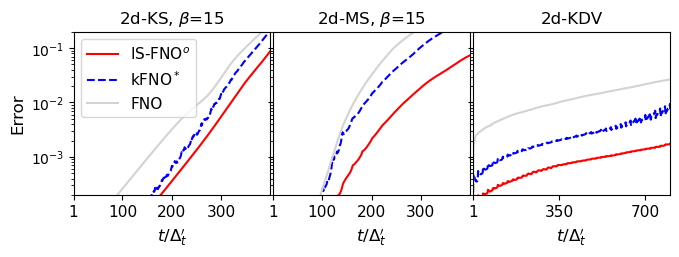

In [66]:
list_title =[   r'2d-KS, $\beta$=15', r'2d-MS, $\beta$=15',  r'2d-KDV'] # , $\beta$=10' ]
All_list_PDE =[  '', '', 'KDV']
All_list_para_values =[     [15,0],    [15,1] , [10,0]  ]
All_list_model_names =[ ['RevtFNO150_n', 'tFNO150','tFNO150_k1' ] , 
                        ['RevtFNO151_n', 'tFNO151','tFNO151_k1' ] , #'RevtFNO151_e',
                        ['RevtFNO100_n', 'tFNO100','tFNO100_k1' ]  ]

list_models_for_cmp =[ [{'name':model_name, 'para_name':'LpiKDV' if PDE=='KDV' else 'Lpi_rho', 'each_para_value':list_para_values, 'PDE':PDE  } for model_name in All_list_model_names[idx]  ] 
                         for idx, (list_para_values, PDE )  in enumerate( zip(All_list_para_values, All_list_PDE) )  ] 

#line_legend = ['r-', 'b--','g-.','k-','b:', 'b-','b:'] 
line_legend = ['r-', 'b--','lightgrey','k-','b:', 'b-','b:'] 

png_filename= 'ave_err_2d_isFNO.eps'
plot_compressed_errors(list_title, list_models_for_cmp, line_legend,  png_filename=png_filename)

NameError: name 'ss' is not defined

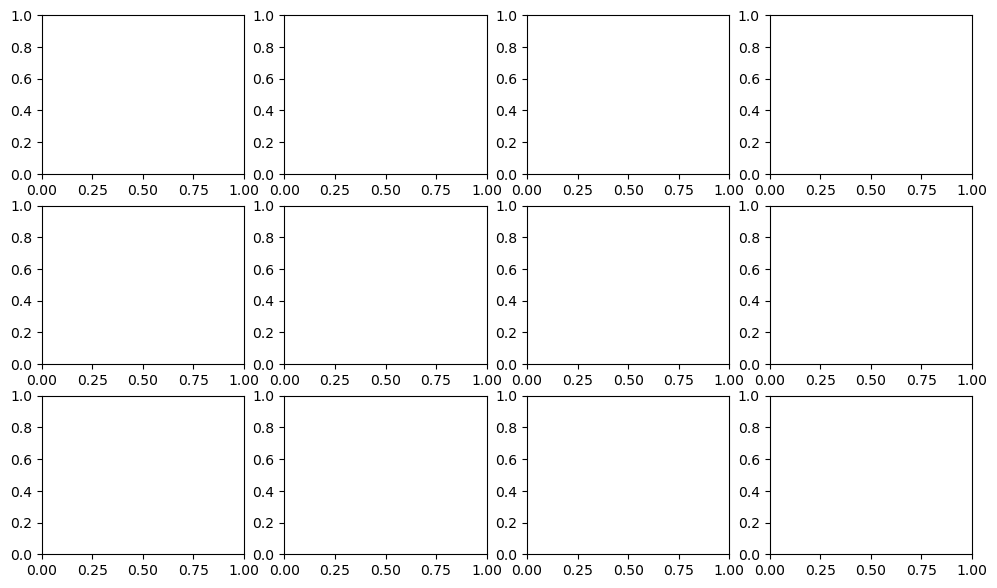

In [43]:
from matplotlib import cm



MMM = 4
fig,axs = plt.subplots(3,MMM, figsize=(12,7))
j = 2
#cm_cmap = cm.RdYlBu
cm_cmap = cm.rainbow

for i in range(MMM):
   #CS = 
   CS = axs[0,i].contourf( test_all_KDV[j,  100*i,:,:], levels= ss*2 , cmap=cm_cmap )
   #CS2 = axs[0,i].contour(CS, levels=CS.levels[::5], colors='k')

   axs[1,i].contourf( test_all[0,0,j,  100*i,:,:], levels= ss*2  , cmap=cm_cmap )
   axs[2,i].contourf( test_all[0,2,j,  100*i,:,:], levels= ss*12  , cmap=cm_cmap )

   axs[0,i].axis('off')
   axs[1,i].axis('off')
   axs[2,i].axis('off')

In [ ]:

def plotly_2d( list_data_for_plot, t_times=[ 50,  350, 800], scale_factor=1/15.):
    import plotly.offline as pyo
    import plotly.graph_objs as go
    from plotly.subplots import make_subplots
    # Set notebook mode to work in offline
    pyo.init_notebook_mode()
    #---------------
    import plotly.io as pio
    pio.renderers.default = 'iframe'
    #------------
    str_subplot_title = [r"$t/\Delta_t'={}$".format(t) for t in t_times]
    
    n_rows = len(list_data_for_plot)
    n_cols = len(t_times)
    list_specs = [ [ {'is_3d': True} for _ in range( n_cols ) ]  for _ in range(n_rows) ]
    
    fig = make_subplots(rows=n_rows, cols=n_cols,
                        specs=list_specs,
                        horizontal_spacing = 0.0,  vertical_spacing  = 0.0,
                        subplot_titles = str_subplot_title 
                        )
    
    for i, t in enumerate(t_times) :
        col = i+1
        j=1
        for data_for_plot in list_data_for_plot:
            fig.add_trace(go.Surface(z= data_for_plot[t]*scale_factor, showscale=False ),         row=j,col= col); j=j+1;
        # fig.add_trace(go.Surface(z=test_all[0,2,kkk,t]/15, showscale=False ),                          row=j,col= col); j=j+1;
        # fig.add_trace(go.Surface(z=models[1]['Lpi15rho1_list_pred'][kkk,t,:,:]/15, showscale=False ),  row=j,col= col); j=j+1;
        # fig.add_trace(go.Surface(z=test_all[0,0,kkk,t]/15, showscale=False ),                          row=j,col= col); j=j+1;
        # fig.add_trace(go.Surface(z=models[0]['Lpi15rho0_list_pred'][kkk,t,:,:]/15, showscale=False ),  row=j,col= col); j=j+1;
    
    
    camera = dict(
        up=dict(x=0, y=0, z=1),
        center=dict(x=0, y=0, z= -0.3), 
        eye=dict(x=1, y=1.2, z = 1.2)
    )
    
    scene_dict=dict(zaxis = dict(range=[-1.69,1.69], showgrid = False,showticklabels = False,title=''), 
                    xaxis = dict(              showgrid = False,showticklabels = False,title=''),
                    yaxis = dict(              showgrid = False,showticklabels = False,title=''),
                    aspectratio=dict(x=1, y=1, z=0.6),
                   camera=camera,
                   )
    
    scene_all_update = {f"scene{i+1}": scene_dict for i in range(n_rows*n_cols)}
    
    
    fig.update_layout( **scene_all_update,
                      width=300/1.5*n_cols, height= 700 , # height=700*3/2*3.5/2.2  ,     #width=1500, height=800, 
                      margin=dict(r=0, l=0), # , b=0.1, t=0.1),                  
                      #coloraxis_colorbar=dict( lenmode='fraction', len=.50)
                     )
    fig.update_annotations(font_size=100)

    fig.show()


In [ ]:
#t_times=[ 50,  350, 800]
t_times = [ 75, 150, 300,450,600,1200]
kkk = 8

list_data_for_plot = [ test_all[0,2,kkk], models[1]['Lpi15rho1_list_pred'][kkk] ] 
#list_data_for_plot = [ test_all[0,0,kkk], models[0]['Lpi15rho0_list_pred'][kkk] ] 
plotly_2d(list_data_for_plot,  t_times=t_times, scale_factor=1/15. )

In [ ]:
#list_data_for_plot = [ test_all[0,2,kkk], models[1]['Lpi15rho1_list_pred'][kkk] ] 
kkk = 2
list_data_for_plot = [ test_all[0,0,kkk], models[0]['Lpi15rho0_list_pred'][kkk] ] 
t_times = [ 75, 150, 300,450,600,1200]
plotly_2d(list_data_for_plot,  t_times=t_times, scale_factor=1/15. )

In [ ]:
kkk = 2
list_data_for_plot = [ test_all_KDV[kkk], models_KDV[0]['LpiKDV10_list_pred'][kkk] ] 

t_times = [ 75, 150, 300,450,600,1200]

plotly_2d(list_data_for_plot,  t_times=t_times, scale_factor=1/3. )

In [ ]:
kkk=0
m=-2
pred_key = 'Lpi{}rho{}_list_pred'.format( models[m]['act_para'][0], models[m]['act_para'][1] )
data_kFNO = models[m][pred_key][kkk,:,:,:];

m=-1
pred_key = 'Lpi{}rho{}_list_pred'.format( models[m]['act_para'][0], models[m]['act_para'][1] )
data_FNO = models[m][pred_key][kkk,:,:,:];

In [ ]:
data_kFNO.shape

In [ ]:
All_data = [ test_all[0,1,kkk],  data_kFNO, data_FNO ]

In [ ]:
#kkk
#m

In [ ]:
# import matplotlib.pyplot as plt
# import matplotlib.animation
# from matplotlib.animation import FuncAnimation, PillowWriter 
# import numpy as np
# from matplotlib import cm
# from matplotlib.colors import LightSource

        
# def make_3d_animation(filename=None,  dt_nSkip=1, len_t= 1999 ):
#     fig, axs = plt.subplots(1,3, subplot_kw={"projection": "3d"}, figsize=(15,5))
#     fig.tight_layout()
#     plt.subplots_adjust(wspace=0, hspace=0.)
#     plt.close()
#     #-----
#     #print(N)
#     N=128
#     X=np.linspace(-np.pi,np.pi,N)
#     Y=np.linspace(-np.pi,np.pi,N)
#     X, Y = np.meshgrid(X, Y)
#     ls = LightSource(azdeg=0, altdeg=65);
    
#     def update_plt(t, dt_nSkip=dt_nSkip ):
#         for idx, data in enumerate(All_data):
#             ax = axs[idx]
#             ax.set_box_aspect(None, zoom=1.5)

#             aaa = data[t]/6
#             rgb = ls.shade( aaa, plt.cm.autumn);           ax.clear()
#             ax.plot_surface(X, Y, aaa,  rstride=1, cstride=1, linewidth=0, antialiased=False, facecolors=rgb,) ;
#             ax.set_zlim( [-6,6]); ax.set_axis_off();
            
#         return 

#     ani = matplotlib.animation.FuncAnimation(fig, update_plt, frames=len_t//dt_nSkip, fargs=(dt_nSkip,))
#     if  filename is not None:
#         if 'gif' in filename:           ani.save(filename, writer=PillowWriter(fps=35))
#         elif 'mp' in  filename:         ani.save( filename, writer= matplotlib.animation.FFMpegWriter(fps=35))
#     else: 
#         ani
#     return
##### make_3d_animation( 'DL2D.mp4', dt_nSkip=1, len_t=1999 )

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LightSource


In [ ]:
#test_all_KDV[kkk,t]
#models_KDV[0]['LpiKDV10_list_pred'][kkk,t,:,:]


In [ ]:
fig, axs = plt.subplots(1,3, subplot_kw={"projection": "3d"}, figsize=(12,4))
fig.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0.)


N=128
X=np.linspace(-np.pi,np.pi,N)
Y=np.linspace(-np.pi,np.pi,N)
X, Y = np.meshgrid(X, Y)
ls = LightSource(azdeg=0, altdeg=65); #65

t_list = [50, 250, 800]

for idx, t in enumerate(t_list):
    ax = axs[idx]
    ax.set_box_aspect(None, zoom=1.5)
    aaa = test_all_KDV[0,t]   # data[t]/2
    rgb = ls.shade( aaa, plt.cm.RdYlBu);           ax.clear()
    #rgb = ls.shade( aaa, plt.cm.autumn);           ax.clear()
    ax.plot_surface(X, Y, aaa,   rstride=1, cstride=1, linewidth=0, antialiased=True, facecolors=rgb , alpha=None) ;
    ax.set_zlim( [-5,5]); #ax.set_axis_off();

fig.show()

In [ ]:

import plotly.offline as pyo
import plotly.graph_objs as go
from plotly.subplots import make_subplots
# Set notebook mode to work in offline
pyo.init_notebook_mode()
#---------------
import plotly.io as pio
pio.renderers.default = 'iframe'
#------------

str_subplot_titles = [ r"$t/\Delta_t'={}  \text" .format(t)+r"{("+ name+r")}$" for t in t_List   for name in m_name  ]

fig = make_subplots(rows=1, cols=3,
                    specs=[[{'is_3d': True}, {'is_3d': True} , {'is_3d': True}] ],
                    horizontal_spacing = 0.0,  vertical_spacing  = 0.0,
                    #subplot_titles=str_subplot_titles
                    )

t =  2000-1
#---------------------

for idx, data in enumerate(All_data):
   fig.add_trace(go.Surface(z=data[t]/15, showscale=False ), row=1,col= 1+idx) #1+2)


new_frames =[go.Frame(  data=[ *[ go.Surface( z= my_data[t]/15) for my_data in All_data ]  ],
                   traces=[0,1,2]) for t in range(10)]   # define 20 frames

fig.frames=new_frames



camera = dict(
    up=dict(x=0, y=0, z=1),
    center=dict(x=0, y=0, z= -0.3), 
    eye=dict(x=1, y=1.2, z = 1.2)
)
scene_dict=dict(zaxis = dict(range=[-1.69,1.69], showgrid = False,showticklabels = False,title=''), 
                xaxis = dict(              showgrid = False,showticklabels = False,title=''),
                yaxis = dict(              showgrid = False,showticklabels = False,title=''),
                aspectratio=dict(x=1, y=1, z=0.6),
                camera=camera,
               ) 
fig.update_layout( scene1=scene_dict,scene2= scene_dict, scene3=scene_dict,
                  width=1.5*200*(3), height=1.5*330, 
                  margin=dict(r=0, l=0), # , b=0.1, t=0.1),                  
                  #coloraxis_colorbar=dict( lenmode='fraction', len=.50)
                 )


#-------

# button = dict(label='Play',
#              method='animate',
#              args=[None])
# button = dict(label='Play',
#              method='animate',
#              args=[None, dict(frame=dict(duration=20,redraw=False), 
#                               transition=dict(duration=0),
#                               fromcurrent=True,
#                               mode='immediate')])

# fig.update_layout(updatemenus=[dict(type='buttons',
#                               #showactive=False,
#                               buttons=[button] )]
#                  )

#fig.write_html("Plotly_2D.html")


# fig.update_layout(updatemenus=[dict(type='buttons',
#                               showactive=False,
#                               y=0,
#                               x=1.05,
#                               xanchor='left',
#                               yanchor='bottom',
#                               buttons=[button] )
#                                       ],
#                  width=800, height=500)
                              
# fig.update_layout(yaxis2_range=[0, 5.5], yaxis2_autorange=False)   
#--------

#fig.show()

#import os
#if not os.path.exists("images"):
#    os.mkdir("images")
#fig.write_image("Flame2d_rho0.5beta15.svg")
#fig.write_image("Flame2d_rho0.5beta15.png")
#img_bytes = fig.to_image(format="png")

